# Triagem Preliminar de Risco Cardíaco
### Aplicativo apoiado por Inteligência Artificial


### Índice

- [Contexto do Projeto](#Contexto-do-Projeto)
- [Papel da Inteligência Artificial](#Papel-da-Inteligência-Artificial)
- [Dataset: Heart Disease (UCI)](#Dataset:-Heart-Disease-(UCI))
    - [Carregamento e Tratamento](#Carregamento-e-Tratamento)
- [Distribuição do Colesterol](#Distribuição-do-Colesterol)
- [Conclusão e Próximos Passos](#Conclusão-e-Próximos-Passos)

<br>
<br>

# Contexto do Projeto

- **Aplicativo** de triagem preliminar de risco cardíaco
- Entrada: dados simples de exames de rotina
- Saída: indicação de risco (não é diagnóstico)
- Público-alvo: pessoas em check-up de rotina
- Escopo limitado: alerta, não substitui avaliação médica

<br>
<br>

# Papel da Inteligência Artificial

- Classificador binário: **risco presente** × **risco ausente**
- Aprende padrões a partir de casos clínicos reais
- Atua como motor de decisão por trás da tela de resultado

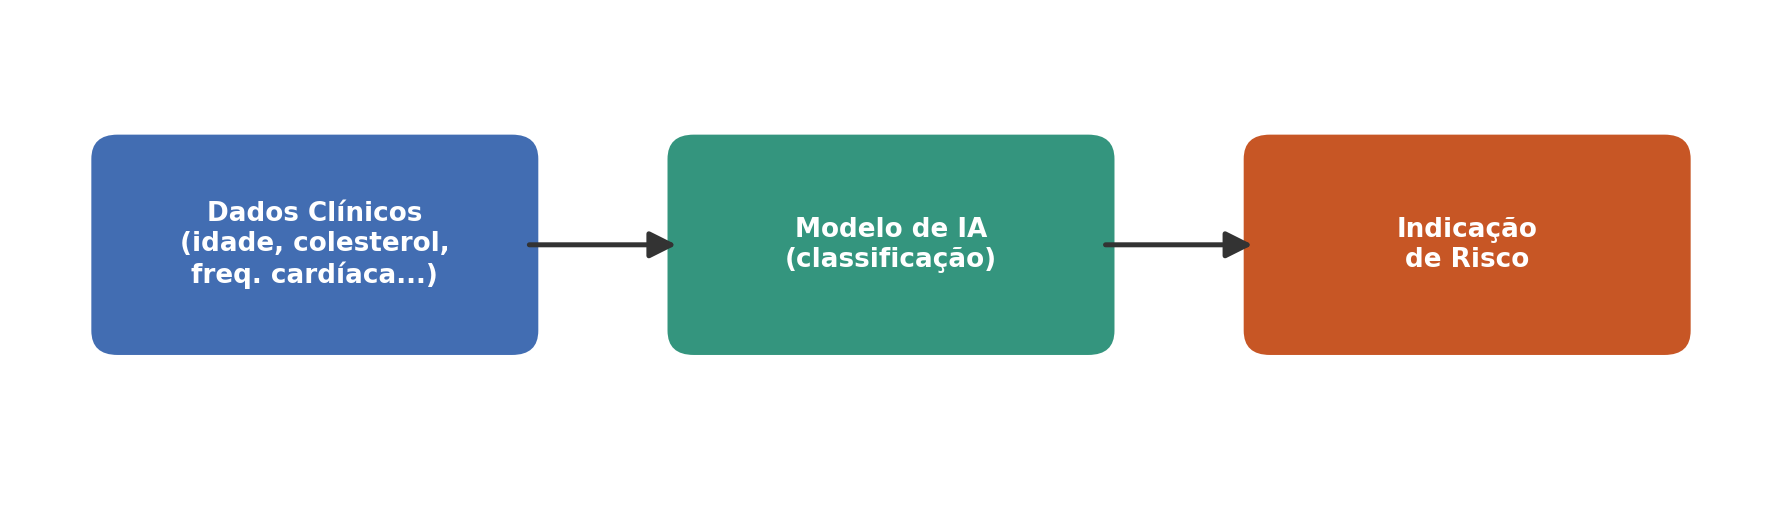

In [ ]:
from IPython.display import Image
Image(filename='images/fluxo_ia.png', width=650)

<br>
<br>

# Dataset: Heart Disease (UCI)

- Fonte: **UCI Machine Learning Repository**
- 303 pacientes, 13 atributos clínicos + alvo
- Alvo: presença (1) ou ausência (0) de doença cardíaca

## Carregamento e Tratamento

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url, header=0, names=cols)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:

df["target"] = (df["target"] > 0).astype(int)
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

<br>
<br>

# Distribuição do Colesterol

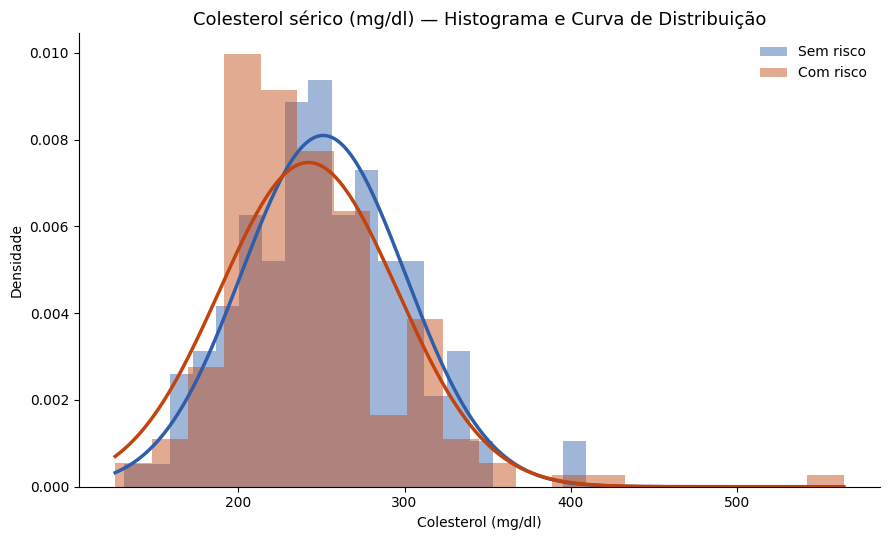

In [ ]:
# @title
chol_sem_risco = df.loc[df["target"] == 0, "chol"]
chol_com_risco = df.loc[df["target"] == 1, "chol"]

x = np.linspace(df["chol"].min(), df["chol"].max(), 300)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(chol_sem_risco, bins=20, density=True, alpha=0.45,
        color="#2E5EAA", label="Sem risco")
ax.hist(chol_com_risco, bins=20, density=True, alpha=0.45,
        color="#C1440E", label="Com risco")

mu0, std0 = norm.fit(chol_sem_risco)
mu1, std1 = norm.fit(chol_com_risco)
ax.plot(x, norm.pdf(x, mu0, std0), color="#2E5EAA", linewidth=2.5)
ax.plot(x, norm.pdf(x, mu1, std1), color="#C1440E", linewidth=2.5)

ax.set_title("Colesterol sérico (mg/dl) — Histograma e Curva de Distribuição", fontsize=13)
ax.set_xlabel("Colesterol (mg/dl)")
ax.set_ylabel("Densidade")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("images/histograma_colesterol.png", dpi=180)
plt.show()